In [1]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
sb.set() 
import re

In [4]:
#train set(training ml models)
train_data = pd.read_csv('train.csv')
train_data.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
#test set (to make predictions)
test_data = pd.read_csv("test.csv")
test_data.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [31]:
#test_labels set (evaluating performance)
testlabels_data = pd.read_csv("test_labels.csv")
testlabels_data.head()

testlabels_clean = testlabels_data[
    (testlabels_data[label_cols] != -1).all(axis=1)
].reset_index(drop=True)

test_eval = test_data.merge(testlabels_clean, on="id")
print("Labelled test rows available for evaluation:", len(test_eval))

Labelled test rows available for evaluation: 63564


In [7]:
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Test Labels shape:", testlabels_data.shape)

Train shape: (159571, 8)
Test shape: (153164, 2)
Test Labels shape: (153164, 7)


In [8]:
print("\nTrain columns:")
print(train_data.columns)

print("\nTest columns:")
print(test_data.columns)


Train columns:
Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')

Test columns:
Index(['id', 'comment_text'], dtype='str')


In [9]:
# train data stats
train_data.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
# test data stats
test_data.describe()

,id,comment_text
count,153164,153164
unique,153164,153164
top,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
freq,1,1


In [11]:
# train dataset info
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


In [12]:
# test dataset info
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            153164 non-null  str  
 1   comment_text  153164 non-null  str  
dtypes: str(2)
memory usage: 2.3 MB


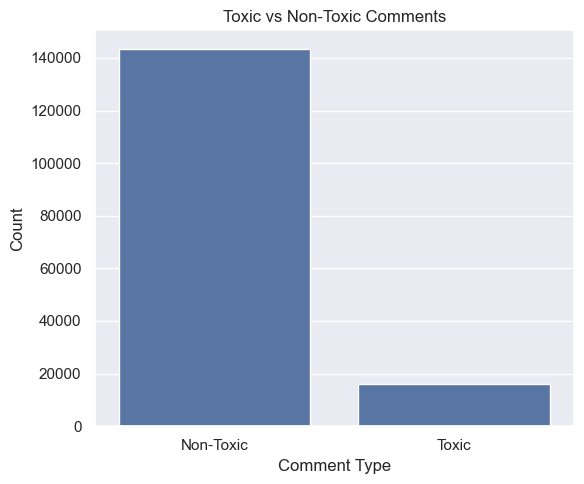

In [13]:
# label columns
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Bar chart: toxic vs non-toxic comments Ctrain set)

train_data["is_toxic_any"] = (train_data[label_cols].sum(axis=1) > 0).astype(int)

toxicity_summary = train_data["is_toxic_any"].value_counts().sort_index()
toxicity_summary.index = ["Non-Toxic", "Toxic"]

plt.figure(figsize=(6, 5))
sb.barplot(x=toxicity_summary.index, y=toxicity_summary.values)
plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Comment Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

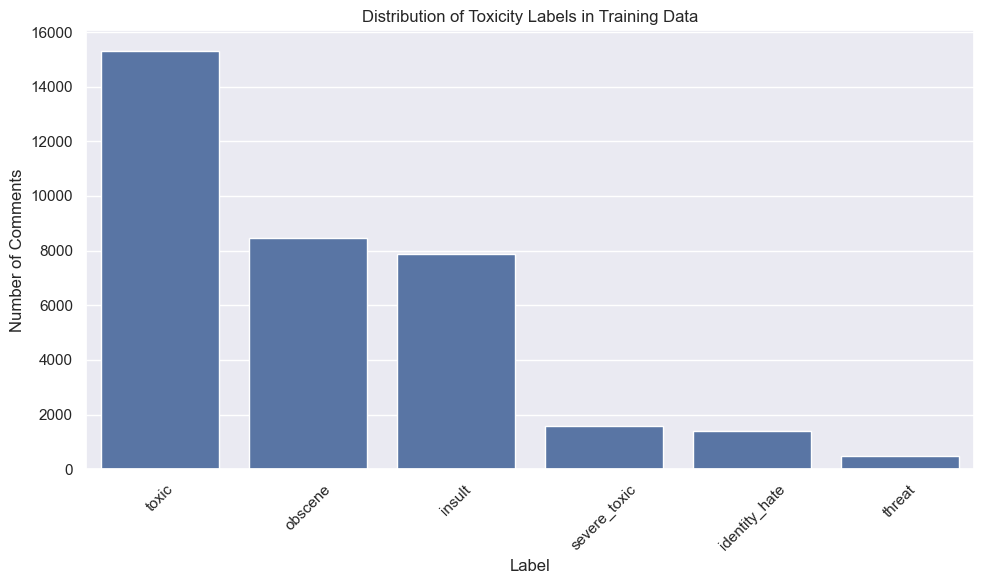

In [14]:
# Bar chart: count of each toxicity label Ctrain set)

label_counts = train_data[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sb.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Distribution of Toxicity Labels in Training Data")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

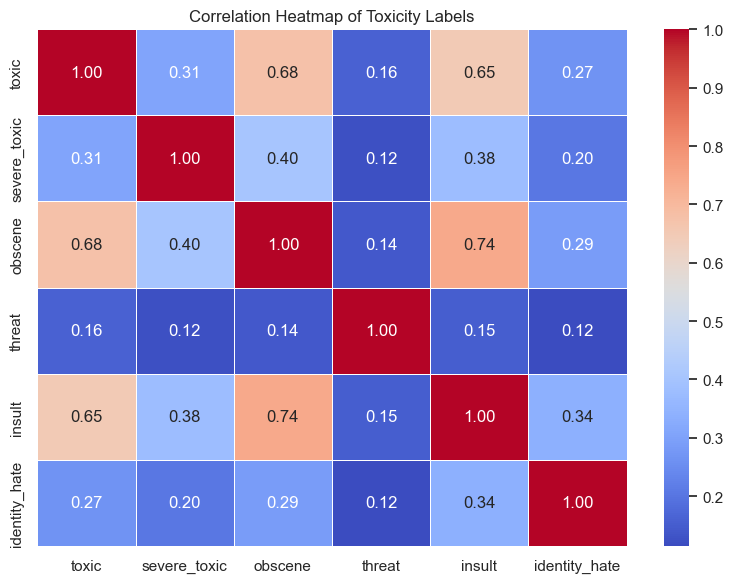

In [15]:
# Heatmap: correlation between toxicity labels Ctrain set)

plt.figure(figsize=(8, 6))
corr_matrix = train_data[label_cols].corr()

sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Toxicity Labels")
plt.tight_layout()
plt.show()

# DATA PREPROCESSING/CLEANING 

- Text Cleaning✔️
- Filling missing values✔️
- TF-IDF with removal of stopwards ✔️ 
- Stemming(impacts TF-IDF performance)❌

In [16]:
#create a text cleaning function to clean raw text

def clean_text(text):
    text = str(text)
    text = text.lower()

    # remove html tags
    text = re.sub(r'<.*?>', ' ', text)

    # expand contractions
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)

    # remove number-containing tokens
    text = re.sub(r'\b\w*\d+\w*\b', ' ', text)

    # keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [17]:
#apply text cleaning on train data
train_data["clean_comment"] = train_data["comment_text"].apply(clean_text)
test_data["clean_comment"] = test_data["comment_text"].apply(clean_text)

In [18]:
#cleaned textual train data
train_data[["comment_text", "clean_comment"]].head(10)

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...
2,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...
3,"""\nMore\nI can't make any real suggestions on ...",more i can not make any real suggestions on im...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...
5,"""\n\nCongratulations from me as well, use the ...",congratulations from me as well use the tools ...
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,cocksucker before you piss around on my work
7,Your vandalism to the Matt Shirvington article...,your vandalism to the matt shirvington article...
8,Sorry if the word 'nonsense' was offensive to ...,sorry if the word nonsense was offensive to yo...
9,alignment on this subject and which are contra...,alignment on this subject and which are contra...


In [19]:
#cleaned textual test data
test_data[["comment_text", "clean_comment"]].head(10)

,comment_text,clean_comment
0,Yo bitch Ja Rule is more succesful then you'll...,yo bitch ja rule is more succesful then you wi...
1,== From RfC == \n\n The title is fine as it is...,from rfc the title is fine as it is imo
2,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",sources zawe ashton on lapland
3,":If you have a look back at the source, the in...",if you have a look back at the source the info...
4,I don't anonymously edit articles at all.,i do not anonymously edit articles at all
5,Thank you for understanding. I think very high...,thank you for understanding i think very highl...
6,Please do not add nonsense to Wikipedia. Such ...,please do not add nonsense to wikipedia such e...
7,:Dear god this site is horrible.,dear god this site is horrible
8,""" \n Only a fool can believe in such numbers. ...",only a fool can believe in such numbers the co...
9,== Double Redirects == \n\n When fixing double...,double redirects when fixing double redirects ...


In [20]:
# remove null values/missing comments in case of any
train_data.dropna(subset=["clean_comment"], inplace=True)
train_data = train_data[train_data["clean_comment"].str.strip() != ""]
train_data.reset_index(drop=True, inplace=True)

test_data.dropna(subset=["clean_comment"], inplace=True)
test_data = test_data[test_data["clean_comment"].str.strip() != ""]
test_data.reset_index(drop=True, inplace=True)

In [21]:
#Final check for any null/missing values
print("Empty comments after cleaning (train data):",
      (train_data["clean_comment"] == "").sum())
print("Empty comments after cleaning (test data):",
      (test_data["clean_comment"] == "").sum())

Empty comments after cleaning (train data): 0
Empty comments after cleaning (test data): 0


In [22]:
#saving cleaned train textual data in new csv file
train_data.to_csv("train_cleaned.csv", index=False)
test_data.to_csv("test_cleaned.csv", index=False)

In [23]:
#Feature Engineering (train set)

train_data["char_count"] = train_data["clean_comment"].apply(len)   # length features
train_data["word_count"] = train_data["clean_comment"].apply(lambda x: len(x.split()))
train_data["exclamation_count"] = train_data["comment_text"].str.count("!")    # punctuation features
train_data["question_count"] = train_data["comment_text"].str.count(r"\?")
train_data["uppercase_ratio"] = train_data["comment_text"].apply(             # uppercase ratio
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
)
#Feature enginering (test set)
test_data["char_count"] = test_data["clean_comment"].apply(len)
test_data["word_count"] = test_data["clean_comment"].apply(lambda x: len(x.split()))
test_data["exclamation_count"] = test_data["comment_text"].str.count("!")
test_data["question_count"] = test_data["comment_text"].str.count(r"\?")
test_data["uppercase_ratio"] = test_data["comment_text"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))

In [24]:
#Separation of text and labels for train set to perform tf-idf
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

X = train_data["clean_comment"]   #tf-idf will be only done on comments, not on labels. 
y = train_data[label_cols]
X_test = test_data["clean_comment"]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(127648,) (31912,)
(127648, 6) (31912, 6)


In [25]:
#Performing TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
custom_stopwords = set(ENGLISH_STOP_WORDS) - {"no", "not", "nor", "never"}

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    stop_words=list(custom_stopwords),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'\b[a-zA-Z]{2,}\b'
)

X_train_tfidf = tfidf.fit_transform(X_train) #fits the model and transforms  data
X_val_tfidf = tfidf.transform(X_val) #only transforms into tf-idf values
X_test_tfidf = tfidf.transform(X_test) #only transforms into tf-idf values

In [29]:
# combine features and tf-idf values into 1 single array (feature engineering)
train_extra = train_data.loc[X_train.index, [
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

val_extra = train_data.loc[X_val.index, [
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

test_extra = test_data[[                          # fixed: reads from test_data, not train_data
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix, hstack

scaler = StandardScaler()

train_extra = scaler.fit_transform(train_extra)
val_extra   = scaler.transform(val_extra)
test_extra  = scaler.transform(test_extra)

X_train_final = hstack([X_train_tfidf, csr_matrix(train_extra)])
X_val_final   = hstack([X_val_tfidf,   csr_matrix(val_extra)])
X_test_final  = hstack([X_test_tfidf,  csr_matrix(test_extra)])

print("X_train_final shape:", X_train_final.shape)
print("X_val_final shape:",   X_val_final.shape)
print("X_test_final shape:",  X_test_final.shape)

X_train_final shape: (127648, 30005)
X_val_final shape: (31912, 30005)
X_test_final shape: (152251, 30005)


In [30]:
#viewing features with highest tf-idf values
row = 0  # choose a document
feature_names = tfidf.get_feature_names_out()
row_values = X_train_tfidf[row].toarray().flatten()

df = pd.DataFrame({
    'feature': feature_names,
    'tfidf': row_values
})

# show only non-zero values
df = df[df['tfidf'] > 0]

# sort by importance
df = df.sort_values(by='tfidf', ascending=False)
print(df.head(10))

                  feature     tfidf
4747            come mind  0.345767
16136  mutually exclusive  0.339791
16135            mutually  0.314315
12043         incorporate  0.291248
8591            exclusive  0.281403
28640             wanting  0.267715
27295              turkey  0.262755
5678              counter  0.249005
12083               india  0.225035
5215          considering  0.224592


#### Summary
1. Load data
2. EDA
3. Clean text and remove null values
4. Feature engineering
5. Train/validation split
6. TF-IDF wiht stopword removal
7. Combine features

# MACHINE LEARNING

#### Variables to be used for Logistic Regression
X_train_final, y_train, X_val_final, y_val will be used to train the Logistic Regression model.

X_test_final/test_data will be used for making final predictions and test_labels is for evaluating performance

In [44]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# Naive Bayes is trained on TF-IDF only (no engineered features)
# because MultinomialNB cannot handle negative values produced by StandardScaler

nb_model = OneVsRestClassifier(MultinomialNB(alpha=0.1))
nb_model.fit(X_train_tfidf, y_train)

# Predictions on validation set
nb_val_preds = nb_model.predict(X_val_tfidf)

print("=== Naive Bayes (Baseline) — Validation Results ===\n")
print(classification_report(y_val, nb_val_preds, target_names=label_cols, zero_division=0))

# Per-label ROC-AUC
nb_val_probs = nb_model.predict_proba(X_val_tfidf)
for i, label in enumerate(label_cols):
    auc = roc_auc_score(y_val[label], nb_val_probs[:, i])
    print(f"ROC-AUC [{label}]: {auc:.4f}")

=== Naive Bayes (Baseline) — Validation Results ===

               precision    recall  f1-score   support

        toxic       0.87      0.58      0.70      3092
 severe_toxic       0.44      0.39      0.42       321
      obscene       0.85      0.61      0.71      1756
       threat       0.47      0.07      0.12       106
       insult       0.76      0.53      0.63      1633
identity_hate       0.42      0.22      0.29       293

    micro avg       0.80      0.55      0.65      7201
    macro avg       0.64      0.40      0.48      7201
 weighted avg       0.80      0.55      0.65      7201
  samples avg       0.05      0.05      0.05      7201

ROC-AUC [toxic]: 0.9506
ROC-AUC [severe_toxic]: 0.9746
ROC-AUC [obscene]: 0.9594
ROC-AUC [threat]: 0.9497
ROC-AUC [insult]: 0.9549
ROC-AUC [identity_hate]: 0.9509


In [ ]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' automatically adjusts weights inversely
# proportional to class frequency — this handles the severe imbalance
# (e.g. only 0.3% of comments are threats)

lr_model = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,                    # regularisation strength (lower = more regularisation)
        solver='saga',            # best solver for large sparse datasets
        class_weight='balanced',  # handles class imbalance
        max_iter=2000,
        random_state=42
    )
)

lr_model.fit(X_train_final, y_train)

# Predictions on validation set
lr_val_preds = lr_model.predict(X_val_final)

print("=== Logistic Regression (Main Model) — Validation Results ===\n")
print(classification_report(y_val, lr_val_preds, target_names=label_cols, zero_division=0))

# Per-label ROC-AUC
lr_val_probs = lr_model.predict_proba(X_val_final)
for i, label in enumerate(label_cols):
    auc = roc_auc_score(y_val[label], lr_val_probs[:, i])
    print(f"ROC-AUC [{label}]: {auc:.4f}")

/Users/Aravinth/Documents/miniconda3/envs/ie0005_25s2/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Aravinth/Documents/miniconda3/envs/ie0005_25s2/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Aravinth/Documents/miniconda3/envs/ie0005_25s2/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Aravinth/Documents/miniconda3/envs/ie0005_25s2/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


=== Logistic Regression (Main Model) — Validation Results ===

               precision    recall  f1-score   support

        toxic       0.61      0.84      0.70      3092
 severe_toxic       0.22      0.89      0.35       321
      obscene       0.63      0.88      0.74      1756
       threat       0.12      0.78      0.21       106
       insult       0.50      0.85      0.63      1633
identity_hate       0.16      0.81      0.26       293

    micro avg       0.47      0.85      0.61      7201
    macro avg       0.37      0.84      0.48      7201
 weighted avg       0.55      0.85      0.66      7201
  samples avg       0.06      0.08      0.06      7201

ROC-AUC [toxic]: 0.9643
ROC-AUC [severe_toxic]: 0.9852
ROC-AUC [obscene]: 0.9841
ROC-AUC [threat]: 0.9787
ROC-AUC [insult]: 0.9721
ROC-AUC [identity_hate]: 0.9725


/Users/Aravinth/Documents/miniconda3/envs/ie0005_25s2/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


: 

In [41]:
# Extract learned weights from Logistic Regression for interpretability

tfidf_feature_names = list(tfidf.get_feature_names_out())
extra_feature_names = ["char_count", "word_count", "exclamation_count", 
                       "question_count", "uppercase_ratio"]
all_feature_names = tfidf_feature_names + extra_feature_names

# Weights for the toxic classifier (index 0)
toxic_weights = lr_model.estimators_[0].coef_[0]

weights_df = pd.DataFrame({
    "feature": all_feature_names,
    "weight": toxic_weights
})

# Top 20 words/bigrams pushing TOWARDS toxic
print("=== Top 20 features INCREASING toxic prediction ===\n")
print(weights_df.sort_values("weight", ascending=False).head(20).to_string(index=False))

# Top 20 words/bigrams pushing AWAY from toxic
print("\n=== Top 20 features DECREASING toxic prediction ===\n")
print(weights_df.sort_values("weight", ascending=True).head(20).to_string(index=False))

# Specifically check negation bigrams
print("\n=== Negation bigrams and their weights ===\n")
negation_mask = weights_df["feature"].str.startswith(("not ", "dont ", "never ", "no "))
print(weights_df[negation_mask].sort_values("weight").head(20).to_string(index=False))

=== Top 20 features INCREASING toxic prediction ===

 feature    weight
    fuck 12.279516
 fucking  9.962632
  stupid  9.102586
    shit  8.859459
   idiot  8.151067
     ass  7.193266
    suck  6.109741
 asshole  6.022477
    crap  5.715484
    dick  5.702877
    hell  5.581075
     gay  5.577951
   bitch  5.538597
bullshit  5.258862
  faggot  4.847034
    cunt  4.846153
   moron  4.702963
pathetic  4.446955
   sucks  4.392053
    hate  4.182204

=== Top 20 features DECREASING toxic prediction ===

      feature    weight
       thanks -4.770330
      article -4.346017
        thank -4.126983
         talk -3.894307
          utc -3.138609
           wp -3.097149
     redirect -3.054005
      section -2.818946
         help -2.582227
redirect talk -2.429345
      sources -2.353596
       source -2.274190
         best -2.203574
   discussion -2.195893
         list -2.124753
         used -1.998999
         link -1.988654
          add -1.941343
        agree -1.935986
     deletion 

: 

In [ ]:
# Macro F1 gives equal weight to each label regardless of frequency
# This is important because rare labels like 'threat' matter just as much

nb_f1 = f1_score(y_val, nb_val_preds, average='macro', zero_division=0)
lr_f1 = f1_score(y_val, lr_val_preds, average='macro', zero_division=0)

print("=== Model Comparison (Macro F1 on Validation Set) ===")
print(f"Naive Bayes (baseline):    {nb_f1:.4f}")
print(f"Logistic Regression (main): {lr_f1:.4f}")
print(f"\nImprovement: {((lr_f1 - nb_f1) / nb_f1) * 100:.1f}%")

# ROC-AUC comparison between Naive Bayes and Logistic Regression
nb_val_probs = nb_model.predict_proba(X_val_tfidf)
lr_val_probs = lr_model.predict_proba(X_val_final)

print("=== Model Comparison (ROC-AUC per label on Validation Set) ===\n")
print(f"{'Label':<20} {'Naive Bayes':<15} {'Logistic Regression':<20}")
print("-" * 55)

nb_aucs = []
lr_aucs = []

for i, label in enumerate(label_cols):
    nb_auc = roc_auc_score(y_val[label], nb_val_probs[:, i])
    lr_auc = roc_auc_score(y_val[label], lr_val_probs[:, i])
    nb_aucs.append(nb_auc)
    lr_aucs.append(lr_auc)
    print(f"{label:<20} {nb_auc:<15.4f} {lr_auc:<20.4f}")

print("-" * 55)
print(f"{'Mean ROC-AUC':<20} {sum(nb_aucs)/len(nb_aucs):<15.4f} {sum(lr_aucs)/len(lr_aucs):<20.4f}")

=== Model Comparison (Macro F1 on Validation Set) ===
Naive Bayes (baseline):    0.4754
Logistic Regression (main): 0.4687

Improvement: -1.4%
=== Model Comparison (ROC-AUC per label on Validation Set) ===

Label                Naive Bayes     Logistic Regression 
-------------------------------------------------------
toxic                0.9506          0.9584              
severe_toxic         0.9746          0.9847              
obscene              0.9594          0.9815              
threat               0.9497          0.9773              
insult               0.9549          0.9683              
identity_hate        0.9509          0.9709              
-------------------------------------------------------
Mean ROC-AUC         0.9567          0.9735              


: 

In [36]:
# Prepare test features — same pipeline as training
# test_eval was created when you filtered out -1 rows from test_labels

X_test_eval = test_eval["clean_comment"]

# Engineer features for test_eval comments
test_eval_extra = test_eval[[
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

# Apply the SAME scaler fitted on training data (do not refit)
test_eval_extra_scaled = scaler.transform(test_eval_extra)

# TF-IDF transform only (do not refit)
X_test_eval_tfidf = tfidf.transform(X_test_eval)

# Combine
from scipy.sparse import csr_matrix, hstack
X_test_eval_final = hstack([X_test_eval_tfidf, csr_matrix(test_eval_extra_scaled)])

# Final predictions
y_test_true = test_eval[label_cols]
lr_test_preds = lr_model.predict(X_test_eval_final)
lr_test_probs = lr_model.predict_proba(X_test_eval_final)

print("=== Logistic Regression — Final Test Set Results ===\n")
print(classification_report(y_test_true, lr_test_preds, target_names=label_cols, zero_division=0))

for i, label in enumerate(label_cols):
    auc = roc_auc_score(y_test_true[label], lr_test_probs[:, i])
    print(f"ROC-AUC [{label}]: {auc:.4f}")

=== Logistic Regression — Final Test Set Results ===

               precision    recall  f1-score   support

        toxic       0.43      0.87      0.58      6090
 severe_toxic       0.10      0.95      0.17       367
      obscene       0.43      0.87      0.57      3691
       threat       0.08      0.91      0.15       211
       insult       0.35      0.87      0.50      3427
identity_hate       0.13      0.89      0.22       712

    micro avg       0.32      0.87      0.47     14498
    macro avg       0.25      0.89      0.37     14498
 weighted avg       0.38      0.87      0.52     14498
  samples avg       0.05      0.08      0.06     14498

ROC-AUC [toxic]: 0.9451
ROC-AUC [severe_toxic]: 0.9835
ROC-AUC [obscene]: 0.9683
ROC-AUC [threat]: 0.9855
ROC-AUC [insult]: 0.9586
ROC-AUC [identity_hate]: 0.9719


: 

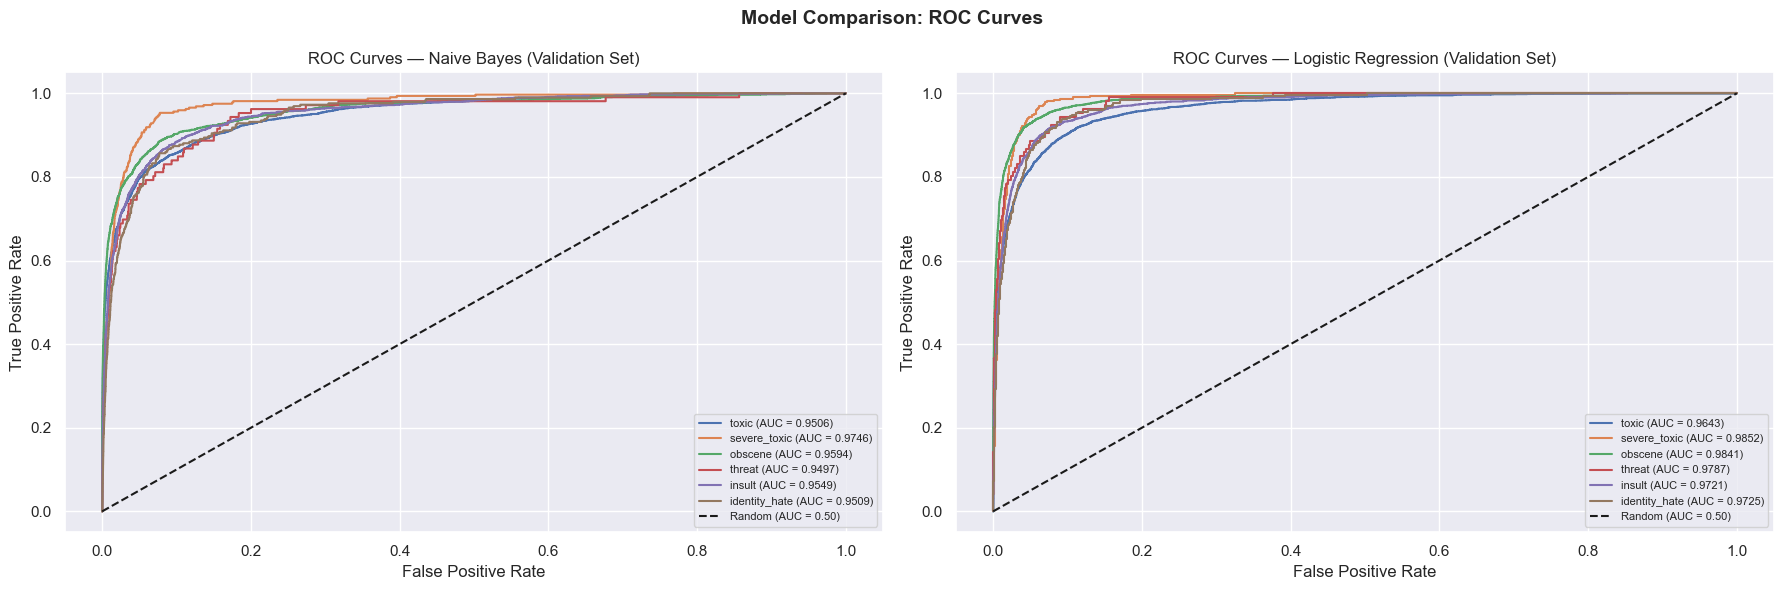

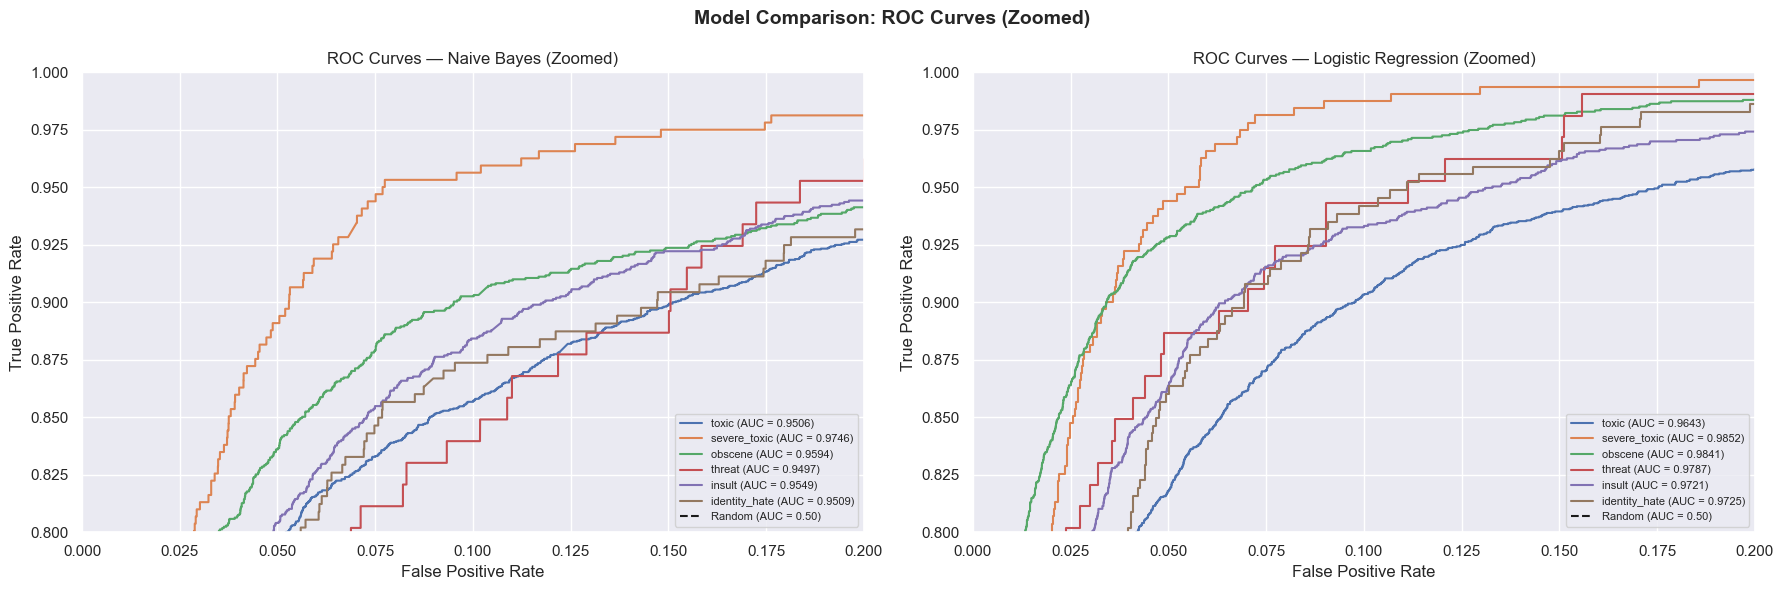

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left chart: Naive Bayes
ax = axes[0]
for i, label in enumerate(label_cols):
    fpr, tpr, _ = roc_curve(y_val[label], nb_val_probs[:, i])
    auc = roc_auc_score(y_val[label], nb_val_probs[:, i])
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.50)")
ax.set_title("ROC Curves — Naive Bayes (Validation Set)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True)

# Right chart: Logistic Regression 
ax = axes[1]
for i, label in enumerate(label_cols):
    fpr, tpr, _ = roc_curve(y_val[label], lr_val_probs[:, i])
    auc = roc_auc_score(y_val[label], lr_val_probs[:, i])
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.50)")
ax.set_title("ROC Curves — Logistic Regression (Validation Set)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True)

plt.suptitle("Model Comparison: ROC Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, probs, title in zip(axes,
                             [nb_val_probs, lr_val_probs],
                             ["Naive Bayes", "Logistic Regression"]):
    for i, label in enumerate(label_cols):
        fpr, tpr, _ = roc_curve(y_val[label], probs[:, i])
        auc = roc_auc_score(y_val[label], probs[:, i])
        ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.4f})")

    ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.50)")
    ax.set_title(f"ROC Curves — {title} (Zoomed)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim([0, 0.2])   # ← zoom into top left corner
    ax.set_ylim([0.8, 1.0]) # ← zoom into top left corner
    ax.grid(True)

plt.suptitle("Model Comparison: ROC Curves (Zoomed)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import f1_score
import numpy as np

# Find optimal threshold per label on validation set
best_thresholds = {}

for i, label in enumerate(label_cols):
    best_f1 = 0
    best_thresh = 0.5
    
    # Try every threshold from 0.1 to 0.9
    for thresh in np.arange(0.1, 0.9, 0.05):
        preds = (lr_val_probs[:, i] >= thresh).astype(int)
        f1 = f1_score(y_val[label], preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    best_thresholds[label] = best_thresh
    print(f"{label:<15} best threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")

print("\nBest thresholds:", best_thresholds)

# Apply per-label optimal thresholds
lr_val_preds_tuned = np.zeros_like(lr_val_probs)
for i, label in enumerate(label_cols):
    lr_val_preds_tuned[:, i] = (lr_val_probs[:, i] >= best_thresholds[label]).astype(int)

print("=== Logistic Regression with Tuned Thresholds — Validation Results ===\n")
print(classification_report(y_val, lr_val_preds_tuned, target_names=label_cols, zero_division=0))

toxic           best threshold: 0.65  F1: 0.7391
severe_toxic    best threshold: 0.85  F1: 0.4423
obscene         best threshold: 0.70  F1: 0.7870
threat          best threshold: 0.85  F1: 0.3434
insult          best threshold: 0.70  F1: 0.6926
identity_hate   best threshold: 0.85  F1: 0.3854

Best thresholds: {'toxic': np.float64(0.6500000000000001), 'severe_toxic': np.float64(0.8500000000000003), 'obscene': np.float64(0.7000000000000002), 'threat': np.float64(0.8500000000000003), 'insult': np.float64(0.7000000000000002), 'identity_hate': np.float64(0.8500000000000003)}
=== Logistic Regression with Tuned Thresholds — Validation Results ===

               precision    recall  f1-score   support

        toxic       0.75      0.73      0.74      3092
 severe_toxic       0.32      0.73      0.44       321
      obscene       0.79      0.79      0.79      1756
       threat       0.25      0.54      0.34       106
       insult       0.65      0.75      0.69      1633
identity_hate      

In [37]:
# BIAS / FAIRNESS EVALUATION
# We measure False Positive Rate (FPR) for comments containing
# identity-related terms vs the overall FPR.
# FPR = non-toxic comments wrongly flagged as toxic / all non-toxic comments
# A significantly higher FPR for a term suggests the model is
# biased against comments mentioning that identity group.

identity_terms = [
    "muslim", "jewish", "christian", "black", "white",
    "gay", "lesbian", "transgender", "woman", "man"
]

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# First compute overall FPR on full test_eval set as our baseline
overall_actual_neg = (y_test_true["toxic"].values == 0)
overall_pred_pos = (lr_test_preds[:, 0] == 1)
overall_fpr = (overall_actual_neg & overall_pred_pos).sum() / overall_actual_neg.sum()

print("=== Bias / Fairness Evaluation ===")
print(f"\nOverall FPR (full test set): {overall_fpr:.4f}")
print(f"\n{'Term':<15} {'Comments':<12} {'Non-Toxic':<12} {'False Pos':<12} {'FPR':<10} {'Bias Flag'}")
print("-" * 70)

bias_results = []

for term in identity_terms:
    # Find test_eval comments containing this identity term
    mask = test_eval["comment_text"].str.contains(term, case=False, na=False)
    subset = test_eval[mask].copy()

    if len(subset) < 10:  # skip terms with too few examples to be meaningful
        print(f"{term:<15} {'too few samples'}")
        continue

    # Engineer features for this subset (same pipeline as before)
    subset_tfidf = tfidf.transform(subset["clean_comment"])
    subset_extra = scaler.transform(subset[[
        "char_count", "word_count",
        "exclamation_count", "question_count",
        "uppercase_ratio"
    ]].values)
    X_subset = hstack([subset_tfidf, csr_matrix(subset_extra)])

    # Get predictions
    subset_preds = lr_model.predict(X_subset)
    subset_true = subset[label_cols].values

    # Compute FPR on 'toxic' label (column index 0)
    actual_neg = (subset_true[:, 0] == 0)   # comments that are truly non-toxic
    predicted_pos = (subset_preds[:, 0] == 1)  # comments model flagged as toxic

    if actual_neg.sum() == 0:
        continue

    false_positives = (actual_neg & predicted_pos).sum()
    fpr = false_positives / actual_neg.sum()

    # Flag if FPR is more than 50% higher than overall FPR
    bias_flag = "⚠️ BIASED" if fpr > overall_fpr * 1.5 else "✅ OK"

    bias_results.append({
        "term": term,
        "total": len(subset),
        "non_toxic": actual_neg.sum(),
        "false_pos": false_positives,
        "fpr": fpr,
        "bias_flag": bias_flag
    })

    print(f"{term:<15} {len(subset):<12} {actual_neg.sum():<12} {false_positives:<12} {fpr:<10.4f} {bias_flag}")

print("-" * 70)
print(f"\nBaseline overall FPR: {overall_fpr:.4f}")
print("⚠️ = FPR more than 50% above overall baseline (potential bias)")

=== Bias / Fairness Evaluation ===

Overall FPR (full test set): 0.1227

Term            Comments     Non-Toxic    False Pos    FPR        Bias Flag
----------------------------------------------------------------------
muslim          266          231          40           0.1732     ✅ OK
jewish          323          298          54           0.1812     ✅ OK
christian       442          407          56           0.1376     ✅ OK
black           821          736          193          0.2622     ⚠️ BIASED
white           734          654          140          0.2141     ⚠️ BIASED
gay             620          309          176          0.5696     ⚠️ BIASED
lesbian         63           44           13           0.2955     ⚠️ BIASED
transgender     13           12           4            0.3333     ⚠️ BIASED
woman           262          215          72           0.3349     ⚠️ BIASED
man             8157         7655         977          0.1276     ✅ OK
----------------------------------------

: 